In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
# df.drop("index",axis=1,inplace=True)
df.drop("region",axis=1,inplace=True)

In [10]:
df.tail()

,age,sex,bmi,children,smoker,charges
1333,50,male,30.97,3,no,10600.5483
1334,18,female,31.92,0,no,2205.9808
1335,18,female,36.85,0,no,1629.8335
1336,21,female,25.80,0,no,2007.9450
1337,61,female,29.07,0,yes,29141.3603


In [11]:
df.shape

(1338, 6)

In [12]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges'], dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 62.8+ KB


In [14]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [15]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
charges     1337
dtype: int64

In [17]:
df["children"].unique()

array([0, 1, 3, 2, 5, 4])

In [18]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(1)

In [26]:
df=df.drop_duplicates()

In [27]:
df.duplicated().sum()

np.int64(0)

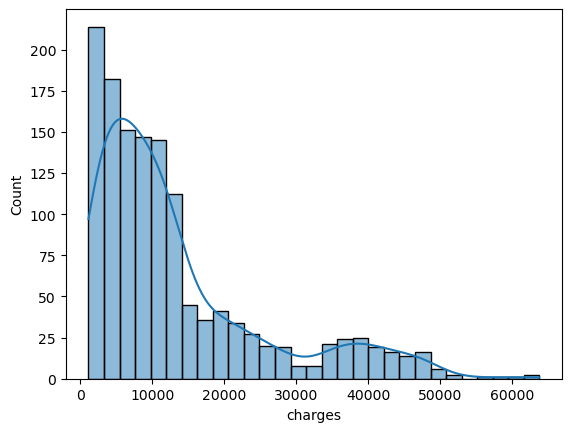

In [31]:
sns.histplot(df["charges"],kde=True)
plt.show()

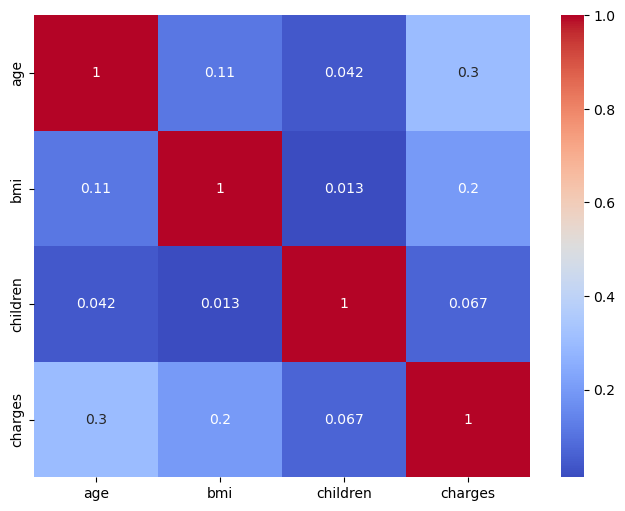

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

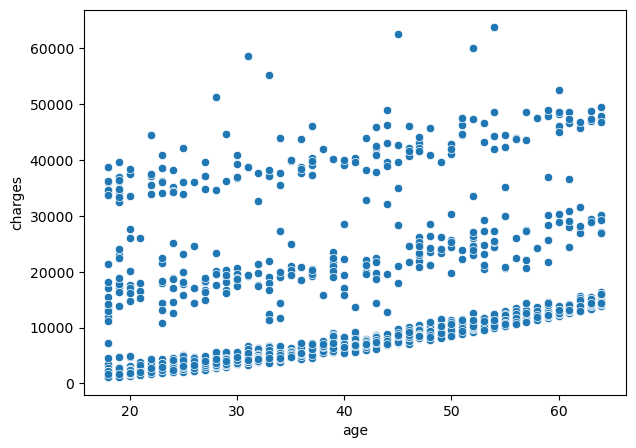

In [33]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="age", y="charges", data=df)
plt.show()

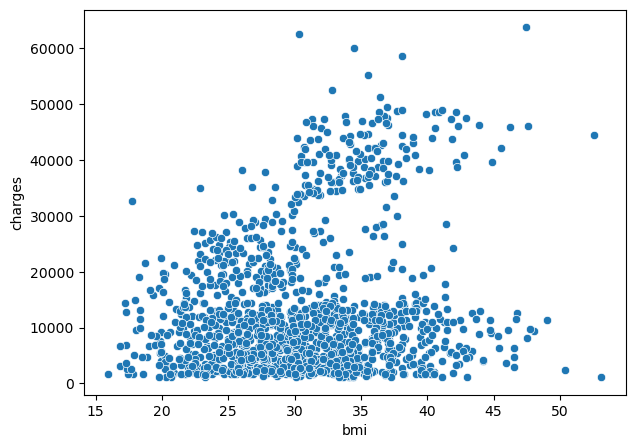

In [34]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.show()

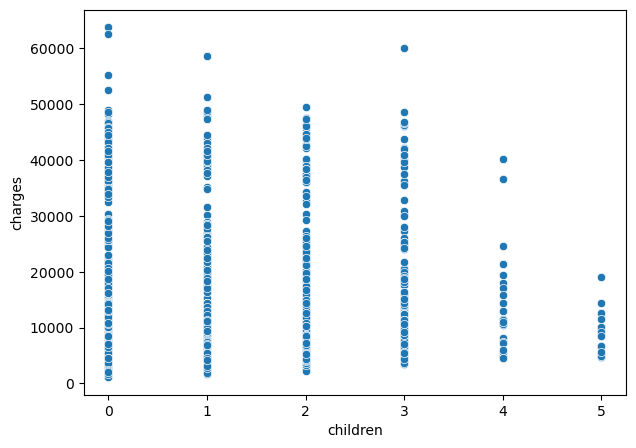

In [35]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="children", y="charges", data=df)
plt.show()

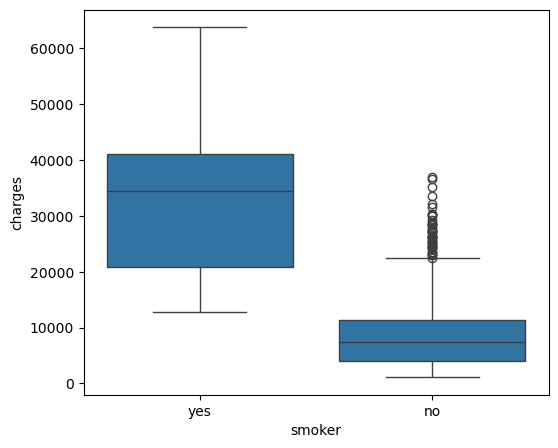

In [36]:
plt.figure(figsize=(6,5))
sns.boxplot(x="smoker", y="charges", data=df)
plt.show()

In [37]:
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

In [38]:
X = df.drop("charges", axis=1 )
y = df["charges"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
model = KNeighborsRegressor()

model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
y_pred = model.predict(X_test)

In [43]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
900,8688.85885,8803.521300
1064,5708.86700,11894.129304
1256,11436.73815,12395.355812
298,38746.35510,39793.936954
237,4463.20510,4851.068460
481,9304.70190,12371.597954
240,38511.62830,42351.722036
277,2150.46900,7087.606018
415,7345.72660,7706.458580
707,10264.44210,9739.163480


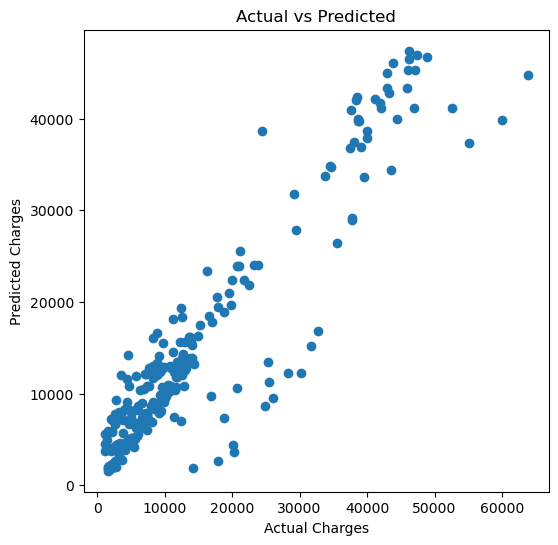

In [44]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

In [45]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.8624312320801821


In [46]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 19],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}

In [47]:
grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,KNeighborsRegressor()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [48]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
Best Cross Validation Score: 0.8114666136998526


In [49]:
best_model = grid.best_estimator_

In [51]:
y_pred = best_model.predict(X_test)
print(r2_score(y_test, y_pred))

0.8764605063025183


In [52]:
joblib.dump(best_model, "insurance_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
metrics = {
    "MAE":  mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "R2 Score": r2,
    "Best Parameters": grid.best_params_,
    "Cross Validation Score": grid.best_score_
}

joblib.dump(metrics, "model_metrics.pkl")